## profiler 
the purpose of this is to know about the datasets and get a good context of the coloumn and the datasets based on the descriptions and create a textual summary of the system so that we can upload it to the vector DB or something else which im thinking 

In [2]:
import os
import pandas as pd
from dotenv import load_dotenv
load_dotenv(dotenv_path='.env')
import json
from datetime import datetime
from typing import TypedDict

# state definition of the profiler

In [3]:
from typing import Annotated

from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages


class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]
    count:int
    target:int

# tools for the profiler


In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode,tools_condition

In [5]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
model=ChatOpenAI(model="gpt-4.1-2025-04-14")

In [6]:
def peek(dataset_count: int) -> str:
    """This helps in getting a peek of the dataset helps you get an idea about the dataset initially about the column name and the values in the first 50 rows to get a brief idea about the dataset"""
    try:
        # Read only the first 50 rows of the dataset
        dataset_path="datasets/"+os.listdir("datasets")[dataset_count-1]
        file_stats = os.stat(dataset_path)
        dataset_name = os.path.basename(dataset_path)
        df = pd.read_csv("datasets/"+os.listdir("datasets")[dataset_count-1], nrows=50)
        
        # Get basic info
        total_rows, total_cols = df.shape
        
        # Create column summary
        column_summary = []
        for col in df.columns:
            col_type = str(df[col].dtype)
            null_count = df[col].isnull().sum()
            unique_count = df[col].nunique()
            
            # Get sample values (first 3 non-null values)
            sample_values = df[col].dropna().head(3).tolist()
            
            column_summary.append(f"Column: {col}")
            column_summary.append(f"  - Data Type: {col_type}")
            column_summary.append(f"  - Null values in sample: {null_count}")
            column_summary.append(f"  - Unique values in sample: {unique_count}")
            column_summary.append(f"  - Sample values: {sample_values}")
            column_summary.append("")
        
        # Create the summary output
        summary = f"""DATASET PEEK SUMMARY: {"datasets/"+os.listdir("datasets")[dataset_count-1]}
        BASIC INFO (First 50 rows):
        - Rows in sample: {total_rows}
        - Total columns: {total_cols}
        - File size: {os.path.getsize("datasets/"+os.listdir("datasets")[dataset_count-1]):,} bytes
        
        COLUMN SUMMARY:
        {chr(10).join(column_summary)}
        
        FIRST 50 ROWS DATA:
        {df.to_string(max_cols=10, max_colwidth=20)}
        
        This peek shows the structure and sample data from the first 50 rows of the dataset."""
        return summary
        
    except Exception as e:
        return f"Error reading dataset {dataset_path}: {str(e)}"

In [7]:
import chromadb
from chromadb.config import Settings

dataset_summaries = {}

def update(summary: str, current_count: int) -> dict:
    """Updates the state with the summary for the current dataset and increments count"""
    global dataset_summaries
    
    try:
        # Store in global dict
        dataset_summaries[current_count] = summary
        
        # Create ChromaDB client with proper configuration
        client = chromadb.PersistentClient(path="./chroma_db")
        
        # Alternative approach if the above doesn't work:
        # client = chromadb.Client(Settings(
        #     chroma_db_impl="duckdb+parquet",
        #     persist_directory="./chroma_db"
        # ))
        
        # Get or create collection
        collection = client.get_or_create_collection("dataset_summaries")
        
        # Check if datasets directory exists and has files
        datasets_dir = "datasets"
        if not os.path.exists(datasets_dir):
            print(f"Warning: {datasets_dir} directory not found")
            dataset_name = f"dataset_{current_count}"
        else:
            dataset_files = os.listdir(datasets_dir)
            if current_count < len(dataset_files):
                dataset_name = dataset_files[current_count]
            else:
                print(f"Warning: current_count {current_count} exceeds available datasets")
                dataset_name = f"dataset_{current_count}"
        
        # Check if document already exists
        doc_id = dataset_name
        try:
            existing = collection.get(ids=[doc_id])
            if existing['ids']:
                # Update existing document
                collection.update(
                    ids=[doc_id],
                    documents=[summary],
                    metadatas=[{"dataset_name": dataset_name, "dataset_id": current_count}]
                )
                print(f"Updated existing document: {doc_id}")
            else:
                # Add new document
                collection.add(
                    documents=[summary],
                    metadatas=[{"dataset_name": dataset_name, "dataset_id": current_count}],
                    ids=[doc_id]
                )
                print(f"Added new document: {doc_id}")
        except Exception as e:
            # If get fails, assume document doesn't exist and add it
            collection.add(
                documents=[summary],
                metadatas=[{"dataset_name": dataset_name, "dataset_id": current_count}],
                ids=[doc_id]
            )
            print(f"Added new document: {doc_id}")
        
        # Verify the data was saved
        saved_data = collection.get(ids=[doc_id])
        print(f"Verification - Saved document count: {len(saved_data['ids'])}")
        print(f"ChromaDB updated successfully. Database path: {os.path.abspath('./chroma_db')}")
        
    except Exception as e:
        print(f"Error updating ChromaDB: {str(e)}")
        print(f"Error type: {type(e).__name__}")
        import traceback
        traceback.print_exc()
    
    return {
        "message": [],
        "count": current_count + 1
    }
    

creating the graph 

In [ ]:


def semantic_summary(state):
    "i am semantic summary"
    all_summaries = [v for k, v in dataset_summaries.items() if k != 'database_intent']
    prompt = (
        "You are a data documentation expert. Given the following dataset summaries, "
        "write a comprehensive, detailed, and semantic description of what the entire collection of datasets is about. "
        "Describe the overall purpose, domains, relationships, and analytical potential. "
        "Highlight any patterns, strengths, or limitations. Do NOT repeat the summaries verbatim, but synthesize them into a single, coherent, high-level description.\n\n"
        "DATASET SUMMARIES:\n" + "\n---\n".join(all_summaries) + "\n\nDATABASE INTENT SUMMARY:"
    )
    Model=ChatOpenAI(model="gpt-3.5-turbo")
    result=Model.invoke(prompt)
    summary=result.content
    dataset_summaries['database_intent'] = summary
    return "done"
tools=[peek,update,semantic_summary]
model_with_tools=model.bind_tools(tools)

In [9]:
graph_workflow=StateGraph(State)
def call_model(state):
         messages = [
            SystemMessage(content=f"""You are an expert data profiling agent. Your task is to iteratively profile datasets until the target number is reached.
	•	Current dataset number: {state["count"]}
	•	Target number of datasets: {state["target"]}
For each dataset, generate a comprehensive profiling summary containing the following three sections:
1. Dataset Summary and Use Case
    Start with a section called 'METADATA' that includes:
   - Dataset name
   - File size
   - Creation date
   - Last modified date
	•	Provide a clear, high-level verbal summary of what the dataset is about.
	•	Identify the possible analytical tasks or domains where this dataset can be applied (e.g., classification, regression, forecasting, customer analysis, NLP, etc.).
	•	Express the summary in a general, non-technical tone for easy understanding.
2. Column-wise Description and Statistics
For each column in the dataset:
	•	Start with the exact column name.
	•	Provide a semantic description explaining what the column represents. and for which purpose this coloumn can be used that is the most importatn informatino
	•	Provide a statistical summary, curated to the column type:
	•	Numerical columns: count, mean, std, min, max, percentiles, skewness, kurtosis, missing values.
	•	Categorical columns: number of unique values, mode, top value frequencies, missing values.
	•	Datetime columns: min/max dates, frequency distribution, temporal gaps, granularity.
	•	Text columns: average length, top terms, language (if applicable), missing values.
3. Overall Dataset Metadata and Statistical Summary
	•	Include overall metadata: number of rows, columns, column type distribution (numeric, categorical, datetime, text), total missing values, and file size (if available).
	•	Provide a high-level statistical overview: any imbalance, skewed distributions, sparsity, duplicates, or anomalies.
	•	Comment on the dataset’s overall structure, quality, and readiness for machine learning or analytical tasks.
4. data quality

    after creating the summary call the updating  step 
	1. First, use peek({state["count"]}) to get dataset preview 
2. Create a  summary based the above data and follow the guidelines which i gave u 
3. After creating the summary, call update(summary, {state["count"]}) to store it
4.finally call the semantic summarizer
            """)
        ]+state["messages"]
         response = model_with_tools.invoke(messages)
         return {"messages": [response]}
graph_workflow.add_node("agent", call_model)
graph_workflow.add_node("tools",ToolNode(tools))
graph_workflow.add_edge(START, "agent")
graph_workflow.add_conditional_edges("agent",tools_condition)
graph_workflow.add_edge("tools", "agent")
agent=graph_workflow.compile()

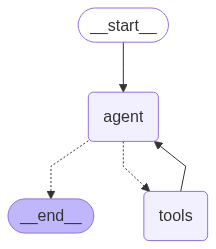

In [10]:
from IPython.display import Image,display
display(Image(agent.get_graph().draw_mermaid_png()))

In [11]:
initial_state = {
    "messages": [],
    "count": 0,
    "target": 2
}

# Synchronous streaming
for step in agent.stream(initial_state):
    print("Step:", step)

Step: {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_iFKO2k0sJzMZ9gFVtjeb3AEm', 'function': {'arguments': '{"dataset_count":0}', 'name': 'peek'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 623, 'total_tokens': 637, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': None, 'id': 'chatcmpl-BuykiSwR9Sm827lovgPO9fUjNGII6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--080f0d61-9428-46a5-9cc7-93147f0a3c7d-0', tool_calls=[{'name': 'peek', 'args': {'dataset_count': 0}, 'id': 'call_iFKO2k0sJzMZ9gFVtjeb3AEm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 623, 'output_tokens': 14, 'total_tokens': 637, 'input_token_details

In [12]:
import json

# Save dataset_summaries to a file
with open("dataset_summaries.json", "w") as f:
    json.dump(dataset_summaries, f)